In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import AdaBoostRegressor

import joblib
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = r"X:\nasim_xhqpjmy\Code\MLops\Race-Telemetry\dataset\data.csv"
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(94519, 73)


,Unnamed: 0,since_last_ns,timestamp_ms,current_engine_rpm,wheel_rotation_speed_front_left,wheel_rotation_speed_front_right,wheel_rotation_speed_rear_left,wheel_rotation_speed_rear_right,wheel_on_rumble_strip_front_left,wheel_on_rumble_strip_front_right,...,clutch,handbrake,gear,steer,lap_number,best_lap_time,last_lap_time,current_lap_time,current_race_time,race_position
0,0,0,27901812,4985.9053,66.646460,66.550380,65.249550,65.155790,False,False,...,0,0,2,1,0,0.0,0.0,0.000000,0.000000,1
1,1,7438900,27901828,4985.5083,66.634400,66.541245,65.254670,65.164270,False,False,...,0,0,2,1,0,0.0,0.0,0.008331,0.008331,1
2,2,8171000,27901828,4964.7420,66.630806,66.537970,65.239240,65.138350,False,False,...,0,0,2,1,0,0.0,0.0,0.016670,0.016670,1
3,3,8336100,27901843,4949.4760,66.613190,66.528110,65.206604,65.110146,False,False,...,0,0,2,1,0,0.0,0.0,0.025003,0.025003,1
4,4,8430500,27901843,4939.9850,66.604416,66.525300,65.134160,65.053990,False,False,...,0,0,2,1,0,0.0,0.0,0.033348,0.033348,1


In [3]:
df = df.copy()
df = df.fillna(0)

# Remove invalid target rows
df = df[df["current_lap_time"] > 0]

print("Cleaned shape:", df.shape)

Cleaned shape: (94518, 73)


In [4]:
# Wheel slip magnitude
df["wheel_slip_magnitude_front"] = np.sqrt(
    df["tire_slip_rotation_front_left"]**2 +
    df["tire_slip_rotation_front_right"]**2
)

df["wheel_slip_magnitude_rear"] = np.sqrt(
    df["tire_slip_rotation_rear_left"]**2 +
    df["tire_slip_rotation_rear_right"]**2
)

# Tire stress
df["tire_stress_front"] = (
    df["tire_combined_slip_front_left"] +
    df["tire_combined_slip_front_right"]
) / 2

df["tire_stress_rear"] = (
    df["tire_combined_slip_rear_left"] +
    df["tire_combined_slip_rear_right"]
) / 2

# Average tire temperature
df["avg_tire_temp"] = (
    df["tire_temp_front_left"] +
    df["tire_temp_front_right"] +
    df["tire_temp_rear_left"] +
    df["tire_temp_rear_right"]
) / 4

# Acceleration & velocity magnitude
df["acceleration_magnitude"] = np.sqrt(
    df["acceleration_x"]**2 +
    df["acceleration_y"]**2 +
    df["acceleration_z"]**2
)

df["velocity_magnitude"] = np.sqrt(
    df["velocity_x"]**2 +
    df["velocity_y"]**2 +
    df["velocity_z"]**2
)

# Steering rate
df["steering_rate"] = df["steer"].diff().fillna(0)

# RPM-speed ratio
df["rpm_speed_ratio"] = df["current_engine_rpm"] / (df["speed"] + 1)

print("Wheel slip magnitude front:", df["wheel_slip_magnitude_front"].head())
print("Wheel slip magnitude rear:", df["wheel_slip_magnitude_rear"].head())
print("Tire stress front:", df["tire_stress_front"].head())
print("Tire stress rear:", df["tire_stress_rear"].head())
print("Average tire temperature:", df["avg_tire_temp"].head())
print("Acceleration magnitude:", df["acceleration_magnitude"].head())
print("Velocity magnitude:", df["velocity_magnitude"].head())
print("Steering rate:", df["steering_rate"].head())
print("RPM-speed ratio:", df["rpm_speed_ratio"].head())
print("Feature engineering completed.")

Wheel slip magnitude front: 1    0.000575
2    0.000617
3    0.000805
4    0.001093
5    0.001142
Name: wheel_slip_magnitude_front, dtype: float64
Wheel slip magnitude rear: 1    0.000227
2    0.002271
3    0.001657
4    0.008228
5    0.009521
Name: wheel_slip_magnitude_rear, dtype: float64
Tire stress front: 1    0.014198
2    0.010561
3    0.000687
4    0.006213
5    0.028870
Name: tire_stress_front, dtype: float64
Tire stress rear: 1    0.011365
2    0.010795
3    0.010709
4    0.012440
5    0.012084
Name: tire_stress_rear, dtype: float64
Average tire temperature: 1    121.802080
2    121.803559
3    121.805011
4    121.806404
5    121.807777
Name: avg_tire_temp, dtype: float64
Acceleration magnitude: 1    2.145005
2    1.679090
3    1.275940
4    0.840998
5    0.643167
Name: acceleration_magnitude, dtype: float64
Velocity magnitude: 1    21.782807
2    21.780424
3    21.777562
4    21.773473
5    21.769059
Name: velocity_magnitude, dtype: float64
Steering rate: 1    0.0
2    0.0
3 

In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'since_last_ns', 'timestamp_ms', 'current_engine_rpm', 'wheel_rotation_speed_front_left', 'wheel_rotation_speed_front_right', 'wheel_rotation_speed_rear_left', 'wheel_rotation_speed_rear_right', 'wheel_on_rumble_strip_front_left', 'wheel_on_rumble_strip_front_right', 'wheel_on_rumble_strip_rear_left', 'wheel_on_rumble_strip_rear_right', 'wheel_in_puddle_depth_front_left', 'wheel_in_puddle_depth_front_right', 'wheel_in_puddle_depth_rear_left', 'wheel_in_puddle_depth_rear_right', 'tire_slip_rotation_front_left', 'tire_slip_rotation_front_right', 'tire_slip_rotation_rear_left', 'tire_slip_rotation_rear_right', 'tire_slip_angle_front_left', 'tire_slip_angle_front_right', 'tire_slip_angle_rear_left', 'tire_slip_angle_rear_right', 'tire_combined_slip_front_left', 'tire_combined_slip_front_right', 'tire_combined_slip_rear_left', 'tire_combined_slip_rear_right', 'tire_temp_front_left', 'tire_temp_front_right', 'tire_temp_rear_left', 'tire_temp_rear_right', 'normalized_suspension

In [6]:
# 1. Drop CSV index junk
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

# 2. Drop time-related columns
TIME_COLS = ["timestamp_ms", "since_last_ns"]
df.drop(columns=[c for c in TIME_COLS if c in df.columns], inplace=True)

# 3. Final safety check on target
df = df[df["current_lap_time"] > 0]

print("Final shape after cleanup:", df.shape)

Final shape after cleanup: (94518, 79)


In [7]:
df.columns

Index(['current_engine_rpm', 'wheel_rotation_speed_front_left',
       'wheel_rotation_speed_front_right', 'wheel_rotation_speed_rear_left',
       'wheel_rotation_speed_rear_right', 'wheel_on_rumble_strip_front_left',
       'wheel_on_rumble_strip_front_right', 'wheel_on_rumble_strip_rear_left',
       'wheel_on_rumble_strip_rear_right', 'wheel_in_puddle_depth_front_left',
       'wheel_in_puddle_depth_front_right', 'wheel_in_puddle_depth_rear_left',
       'wheel_in_puddle_depth_rear_right', 'tire_slip_rotation_front_left',
       'tire_slip_rotation_front_right', 'tire_slip_rotation_rear_left',
       'tire_slip_rotation_rear_right', 'tire_slip_angle_front_left',
       'tire_slip_angle_front_right', 'tire_slip_angle_rear_left',
       'tire_slip_angle_rear_right', 'tire_combined_slip_front_left',
       'tire_combined_slip_front_right', 'tire_combined_slip_rear_left',
       'tire_combined_slip_rear_right', 'tire_temp_front_left',
       'tire_temp_front_right', 'tire_temp_rear_lef

In [8]:
NUMERIC_FEATURES = [
    "speed",
    "current_engine_rpm",
    "acceleration_magnitude",
    "velocity_magnitude",
    "tire_stress_front",
    "tire_stress_rear",
    "wheel_slip_magnitude_front",
    "wheel_slip_magnitude_rear",
    "avg_tire_temp",
    "power",
    "torque",
    "boost",
    "yaw",
    "pitch",
    "roll",
    "steer",
    "rpm_speed_ratio"
]

CATEGORICAL_FEATURES = [
    "gear",
    "lap_number",
    "race_position"
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

LABEL_COLUMNS = [
    "current_lap_time",   # regression
    "gear"                # classification
]

In [9]:
os.makedirs("data/processed", exist_ok=True)

ENGINEERED_PATH = "data/processed/telemetry_features.csv"
ENGINEERED_COLUMNS = list(dict.fromkeys(ALL_FEATURES + LABEL_COLUMNS))
df[ENGINEERED_COLUMNS].to_csv(ENGINEERED_PATH,index=False)

print("Saved engineered dataset (task-agnostic):", ENGINEERED_PATH)

Saved engineered dataset (task-agnostic): data/processed/telemetry_features.csv


In [10]:
df_feat = pd.read_csv(ENGINEERED_PATH)

train_val, test = train_test_split(
    df_feat, test_size=0.15, random_state=42
)

train, val = train_test_split(
    train_val, test_size=0.1765, random_state=42
)

os.makedirs("data/splits", exist_ok=True)

train.to_csv("data/splits/train.csv", index=False)
val.to_csv("data/splits/val.csv", index=False)
test.to_csv("data/splits/test.csv", index=False)

print("Train:", train.shape)
print("Val  :", val.shape)
print("Test :", test.shape)

Train: (66159, 21)
Val  : (14181, 21)
Test : (14178, 21)


In [11]:
train = pd.read_csv("data/splits/train.csv")
val = pd.read_csv("data/splits/val.csv")

TARGET = "current_lap_time"

X_train = train[ALL_FEATURES]
y_train = train[TARGET]

X_val = val[ALL_FEATURES]
y_val = val[TARGET]

In [12]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("encoder", LabelEncoder())  
])

In [13]:
encoders = {}

for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    encoders[col] = le

In [14]:
scaler = StandardScaler()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_val[NUMERIC_FEATURES] = scaler.transform(X_val[NUMERIC_FEATURES])

In [15]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,

    max_depth=4,          
    min_child_weight=10, 
    gamma=2.0,            # penalizes unnecessary splits

    subsample=0.7,
    colsample_bytree=0.7,

    reg_alpha=0.5,        # L1 regularization
    reg_lambda=1.0,       # L2 regularization

    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=2.0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=-1, num_parallel_tree=None, ...)

In [16]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

train_metrics = metrics(y_train, model.predict(X_train))
val_metrics = metrics(y_val, model.predict(X_val))

print("TRAIN → RMSE | MAE | R2:", train_metrics)
print("VAL   → RMSE | MAE | R2:", val_metrics)

TRAIN → RMSE | MAE | R2: (9.03663753851781, 5.809354044130938, 0.9606631459783402)
VAL   → RMSE | MAE | R2: (9.162567748024651, 5.879089106333462, 0.9594364515603147)


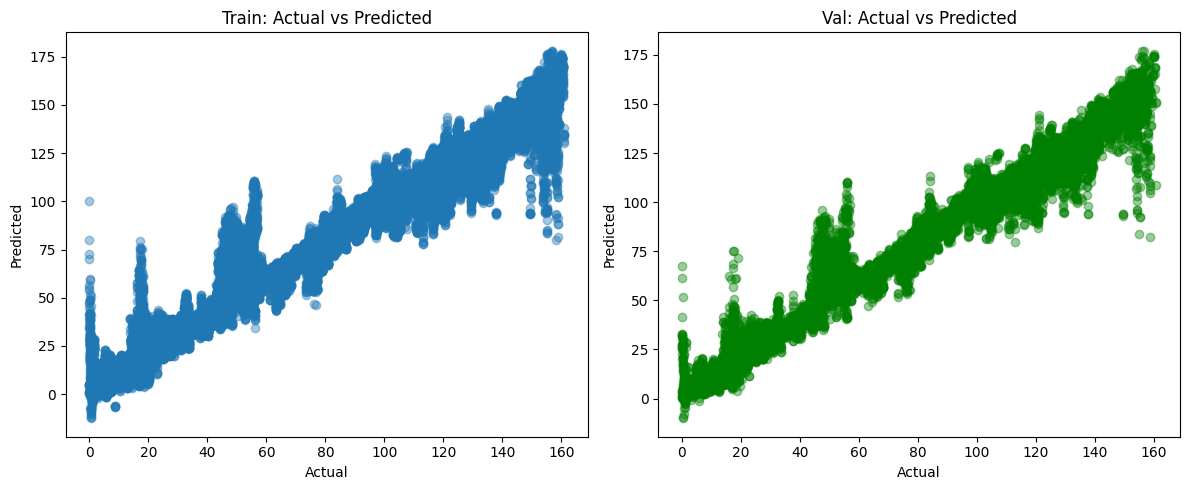

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_train, model.predict(X_train), alpha=0.4)
plt.title("Train: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1,2,2)
plt.scatter(y_val, model.predict(X_val), alpha=0.4, color="green")
plt.title("Val: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [18]:
os.makedirs("artifacts", exist_ok=True)

model.save_model("artifacts/xgb_model.json")
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(encoders, "artifacts/label_encoders.pkl")

print("Model & preprocessors saved.")


Model & preprocessors saved.


In [19]:
from xgboost import XGBRegressor
import joblib

# Load model
loaded_model = XGBRegressor()
loaded_model.load_model("artifacts/xgb_model.json")

# Load preprocessors
loaded_scaler = joblib.load("artifacts/scaler.pkl")
loaded_encoders = joblib.load("artifacts/label_encoders.pkl")

# Test inference
sample = X_val.iloc[:5]
preds = loaded_model.predict(sample)

print(preds)


[ 24.254274 108.401115  13.645821 142.52109   64.59518 ]


In [20]:
print("Preds:", preds)
print("Actual:", y_val.iloc[:5].values)


Preds: [ 24.254274 108.401115  13.645821 142.52109   64.59518 ]
Actual: [ 21.4682   109.64523   15.193097 134.66364   50.511692]


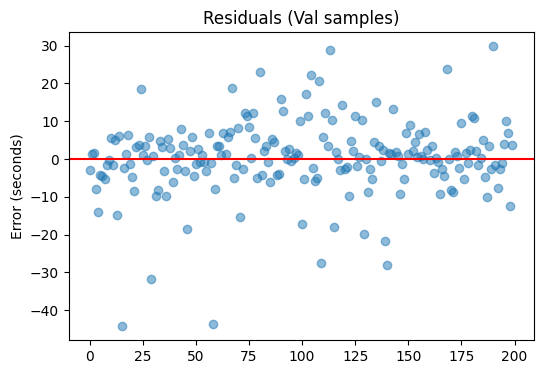

In [ ]:
residuals = y_val.iloc[:200] - model.predict(X_val.iloc[:200])

plt.figure(figsize=(6,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.5)
plt.axhline(0, color="red")
plt.title("Residuals (Val samples)")
plt.ylabel("Error (seconds)")
plt.show()